In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

from xgboost import XGBRegressor

import pickle

In [4]:
df=pd.read_csv("demand_forecasting.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [5]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [12]:
features=[
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [13]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [14]:
target="Demand"

In [16]:
X=df[features].copy()
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [17]:
y=df[target]
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [18]:
label_encoders={}
categorical_cols=X.select_dtypes(include="object").columns

In [19]:
categorical_cols

Index(['Category'], dtype='object')

In [20]:
for col in categorical_cols:
    le=LabelEncoder()
    X[col]=le.fit_transform(X[col])
    label_encoders[col]=le

In [21]:
label_encoders

{'Category': LabelEncoder()}

In [22]:
X_train,X_test ,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [23]:
xgb=XGBRegressor(objective="reg:squarederror",n_jobs=-1)

In [24]:
param_dict={
    "n_estimators":[200,300,500],
    "max_depth":[3,4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0],
    "min_child_weight":[1,3,5]
}

In [25]:
random_search=RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [26]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [27]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [28]:
best_model=random_search.best_estimator_

In [30]:
y_pred=best_model.predict(X_test)

In [31]:
mean_squared_error(y_test,y_pred,squared=False)

35.61727476893841

In [32]:
best_model.feature_importances_

array([0.06661139, 0.01872693, 0.01884814, 0.61624247, 0.02264988,
       0.25692117], dtype=float32)

In [33]:
features_importance=pd.Series(
    best_model.feature_importances_,
    index=X.columns

).sort_values(ascending=False)


In [34]:
features_importance

Promotion             0.616242
Category              0.256921
Price                 0.066611
Competitor Pricing    0.022650
Inventory Level       0.018848
Discount              0.018727
dtype: float32

<Axes: >

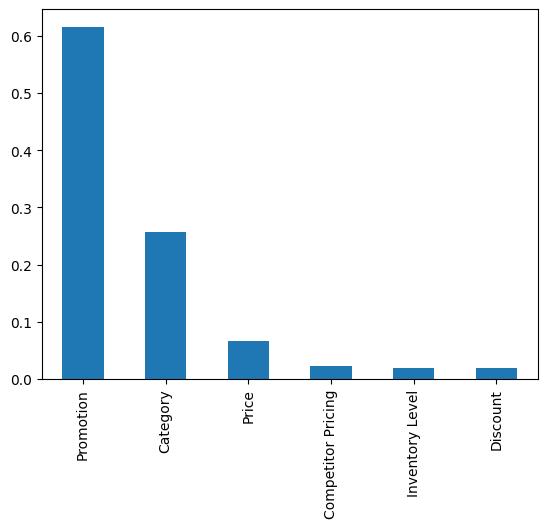

In [35]:
features_importance.plot(kind="bar")

In [36]:
with open("label_encoders.pkl","wb") as f:
    pickle.dump(label_encoders,f)

In [37]:
with open("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model,f)